# ISIC 2019 — Data Preprocessing Pipeline

**Project:** Skin Disease Classification System Using Deep Learning: A Multi-Class Approach  
**Role:** Data pipeline (resizing, normalization, augmentation, stratified split, metadata encoding)

### Pipeline Overview
1. Load & merge CSVs
2. Metadata cleaning & imputation
3. Encode metadata as auxiliary features
4. Stratified train / val / test split (70 / 15 / 15)
5. Class weight computation
6. Augmentation pipelines (standard + aggressive for minority classes)
7. PyTorch Dataset & DataLoader
8. Verify split distributions & augmented samples
9. Save split CSVs + class weights

In [14]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = Path('archive')
IMG_DIR  = BASE_DIR / 'ISIC_2019_Training_Input' / 'ISIC_2019_Training_Input'
GT_CSV   = BASE_DIR / 'ISIC_2019_Training_GroundTruth.csv'
META_CSV = BASE_DIR / 'ISIC_2019_Training_Metadata.csv'
OUT_DIR  = Path('data_splits')
OUT_DIR.mkdir(exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
CLASS_NAMES = {
    'MEL':  'Melanoma',
    'NV':   'Melanocytic Nevi',
    'BCC':  'Basal Cell Carcinoma',
    'AK':   'Actinic Keratoses',
    'BKL':  'Benign Keratosis',
    'DF':   'Dermatofibroma',
    'VASC': 'Vascular Lesions',
    'SCC':  'Squamous Cell Carcinoma',
}
CLASSES   = list(CLASS_NAMES.keys())
N_CLASSES = len(CLASSES)
IMG_SIZE  = 224   # EfficientNet / ResNet / DenseNet standard input
SEED      = 42

# Minority classes that get aggressive augmentation
MINORITY_CLASSES = {'DF', 'VASC', 'AK', 'SCC'}

# ImageNet stats for transfer-learning normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


## 1. Load & Merge CSVs

In [15]:
gt   = pd.read_csv(GT_CSV)
meta = pd.read_csv(META_CSV)

# Drop UNK rows (no ground-truth label)
if 'UNK' in gt.columns:
    gt = gt[gt['UNK'] == 0].drop(columns=['UNK'])

# Derive single string label from one-hot
gt['label'] = gt[CLASSES].idxmax(axis=1)
gt['label_idx'] = gt['label'].map({c: i for i, c in enumerate(CLASSES)})

# Merge metadata
df = gt.merge(meta, on='image', how='left')

print(f'Total samples : {len(df):,}')
print(f'Columns       : {list(df.columns)}')
df.head()

Total samples : 25,331
Columns       : ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'label', 'label_idx', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex']


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,label,label_idx,age_approx,anatom_site_general,lesion_id,sex
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,1,55.0,anterior torso,NaN,female
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,1,30.0,anterior torso,NaN,female
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,0,60.0,upper extremity,NaN,female
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,1,30.0,upper extremity,NaN,male
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,0,80.0,posterior torso,NaN,male


## 2. Metadata Cleaning & Imputation

Missing values from EDA:
- `age_approx` : 1.7% missing → impute with **per-class median**
- `sex`        : 1.5% missing → impute with **mode** (`male`)
- `anatom_site_general` : 10.4% missing → impute with **`'unknown'`** category

In [16]:
print('=== Before imputation ===')
for col in ['age_approx', 'sex', 'anatom_site_general']:
    n = df[col].isna().sum()
    print(f'  {col:25s}: {n:,} missing ({n/len(df)*100:.1f}%)')

# Age: per-class median imputation
class_age_median = df.groupby('label')['age_approx'].median()
def impute_age(row):
    if pd.isna(row['age_approx']):
        return class_age_median[row['label']]
    return row['age_approx']
df['age_approx'] = df.apply(impute_age, axis=1)

# Sex: global mode
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

# Anatomical site: explicit 'unknown' category
df['anatom_site_general'] = df['anatom_site_general'].fillna('unknown')

print('\n=== After imputation ===')
for col in ['age_approx', 'sex', 'anatom_site_general']:
    n = df[col].isna().sum()
    print(f'  {col:25s}: {n:,} missing')

print(f'\nAge stats  : mean={df["age_approx"].mean():.1f}, std={df["age_approx"].std():.1f}')
print(f'Sex counts :\n{df["sex"].value_counts().to_string()}')
print(f'\nSite counts:\n{df["anatom_site_general"].value_counts().to_string()}')

=== Before imputation ===
  age_approx               : 437 missing (1.7%)
  sex                      : 384 missing (1.5%)
  anatom_site_general      : 2,631 missing (10.4%)

=== After imputation ===
  age_approx               : 0 missing
  sex                      : 0 missing
  anatom_site_general      : 0 missing

Age stats  : mean=54.0, std=18.0
Sex counts :
sex
male      13670
female    11661

Site counts:
anatom_site_general
anterior torso     6915
lower extremity    4990
head/neck          4587
upper extremity    2910
posterior torso    2787
unknown            2631
palms/soles         398
oral/genital         59
lateral torso        54


## 3. Encode Metadata as Auxiliary Features

These will be available as extra inputs for metadata-fused models (optional skip for image-only models).

- `age_norm`    : age scaled to [0, 1] using dataset min/max  
- `sex_enc`     : binary (0=female, 1=male)  
- `site_enc`    : integer-encoded anatomical site (0-8)

In [17]:
# Age normalisation (min-max over full dataset)
age_min, age_max = df['age_approx'].min(), df['age_approx'].max()
df['age_norm'] = (df['age_approx'] - age_min) / (age_max - age_min)

# Sex binary encode
df['sex_enc'] = (df['sex'] == 'male').astype(int)

# Anatomical site label-encode
site_le = LabelEncoder()
df['site_enc'] = site_le.fit_transform(df['anatom_site_general'])
site_mapping = dict(zip(site_le.classes_, site_le.transform(site_le.classes_)))

# Save encoders for inference
meta_info = {
    'age_min': float(age_min),
    'age_max': float(age_max),
    'site_mapping': {k: int(v) for k, v in site_mapping.items()},
    'sex_mapping': {'female': 0, 'male': 1},
    'n_meta_features': 3,  # age_norm, sex_enc, site_enc
}
with open(OUT_DIR / 'meta_encoder_info.json', 'w') as f:
    json.dump(meta_info, f, indent=2)

print('Metadata encoding:')
print(f'  age_norm  : [{df["age_norm"].min():.3f}, {df["age_norm"].max():.3f}]')
print(f'  sex_enc   : {dict(df["sex_enc"].value_counts())}')
print(f'  site_enc  : {len(site_mapping)} categories → {site_mapping}')
print(f'\nSaved meta_encoder_info.json')
df[['image', 'label', 'label_idx', 'age_norm', 'sex_enc', 'site_enc']].head()

Metadata encoding:
  age_norm  : [0.000, 1.000]
  sex_enc   : {1: np.int64(13670), 0: np.int64(11661)}
  site_enc  : 9 categories → {'anterior torso': np.int64(0), 'head/neck': np.int64(1), 'lateral torso': np.int64(2), 'lower extremity': np.int64(3), 'oral/genital': np.int64(4), 'palms/soles': np.int64(5), 'posterior torso': np.int64(6), 'unknown': np.int64(7), 'upper extremity': np.int64(8)}

Saved meta_encoder_info.json


,image,label,label_idx,age_norm,sex_enc,site_enc
0,ISIC_0000000,NV,1,0.647059,0,0
1,ISIC_0000001,NV,1,0.352941,0,0
2,ISIC_0000002,MEL,0,0.705882,0,8
3,ISIC_0000003,NV,1,0.352941,1,8
4,ISIC_0000004,MEL,0,0.941176,1,6


## 4. Stratified Train / Val / Test Split (70 / 15 / 15)

Stratified on `label` to preserve class proportions across all three sets.

In [18]:
# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)

# Second split: temp → 50% val, 50% test  (each = 15% of total)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%)')

Train : 17,731  (70.0%)
Val   : 3,800  (15.0%)
Test  : 3,800  (15.0%)


In [19]:
# Verify class proportions are preserved across all splits
def split_class_dist(df_, name):
    counts = df_['label'].value_counts().reindex(CLASSES)
    pcts   = counts / counts.sum() * 100
    return pd.DataFrame({'Count': counts, f'{name} %': pcts.round(2)})

dist = pd.concat([
    split_class_dist(df,       'Full'),
    split_class_dist(train_df, 'Train'),
    split_class_dist(val_df,   'Val'),
    split_class_dist(test_df,  'Test'),
], axis=1)
dist.index = [CLASS_NAMES[c] for c in CLASSES]
print(dist.to_string())

                         Count  Full %  Count  Train %  Count  Val %  Count  Test %
Melanoma                  4522   17.85   3165    17.85    678  17.84    679   17.87
Melanocytic Nevi         12875   50.83   9012    50.83   1932  50.84   1931   50.82
Basal Cell Carcinoma      3323   13.12   2326    13.12    498  13.11    499   13.13
Actinic Keratoses          867    3.42    607     3.42    130   3.42    130    3.42
Benign Keratosis          2624   10.36   1837    10.36    394  10.37    393   10.34
Dermatofibroma             239    0.94    167     0.94     36   0.95     36    0.95
Vascular Lesions           253    1.00    177     1.00     38   1.00     38    1.00
Squamous Cell Carcinoma    628    2.48    440     2.48     94   2.47     94    2.47


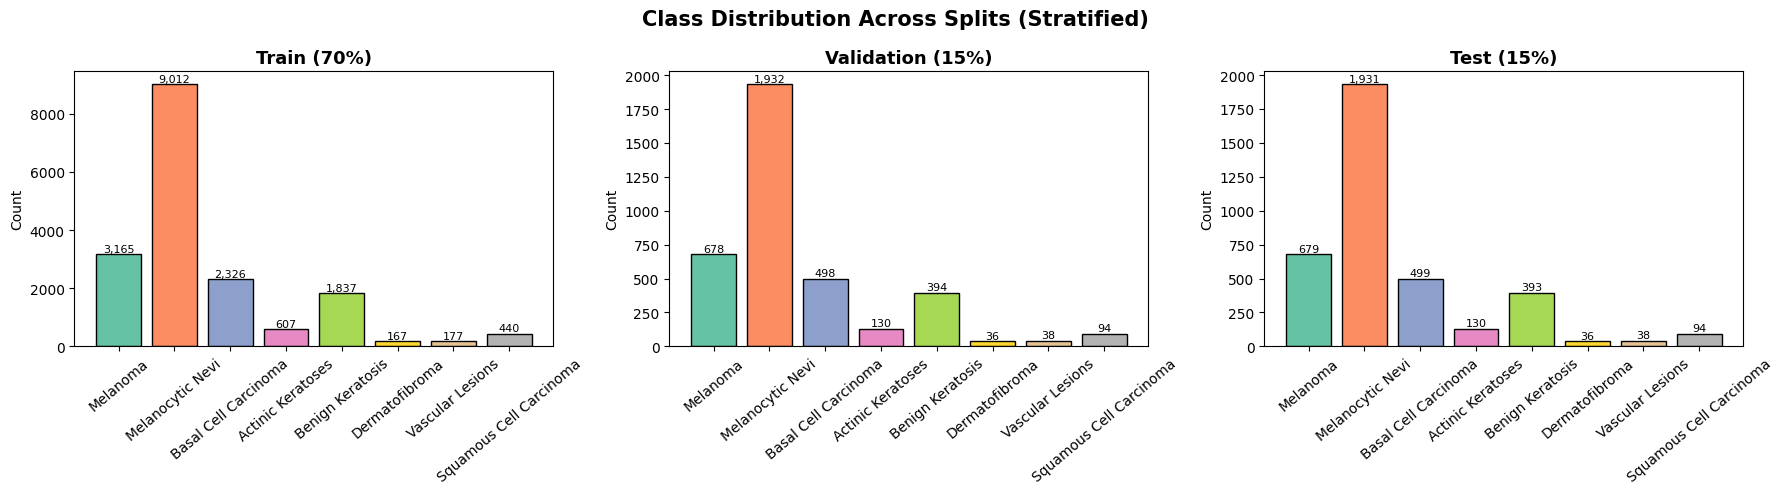

In [20]:
# Visualise split distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
colors = plt.cm.Set2(np.linspace(0, 1, N_CLASSES))
labels = [CLASS_NAMES[c] for c in CLASSES]

for ax, (split_df, title) in zip(axes, [
    (train_df, 'Train (70%)'),
    (val_df,   'Validation (15%)'),
    (test_df,  'Test (15%)'),
]):
    counts = split_df['label'].value_counts().reindex(CLASSES).values
    bars = ax.bar(labels, counts, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=40)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{c:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Class Distribution Across Splits (Stratified)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Class Weight Computation

Computed from **training set only** to avoid data leakage.  
Formula: `w_c = N_total / (N_classes × N_c)`

In [21]:
train_counts = train_df['label'].value_counts().reindex(CLASSES)
class_weights = (len(train_df) / (N_CLASSES * train_counts)).round(4)

cw_df = pd.DataFrame({
    'Disease': [CLASS_NAMES[c] for c in CLASSES],
    'Train Count': train_counts.values,
    'Class Weight': class_weights.values,
}, index=CLASSES)
print(cw_df.to_string())

# As a tensor for PyTorch loss functions
class_weight_tensor = torch.tensor(class_weights.values, dtype=torch.float32)
print(f'\nTensor: {class_weight_tensor}')

# Save for training script
class_weights_dict = {c: float(w) for c, w in zip(CLASSES, class_weights.values)}
with open(OUT_DIR / 'class_weights.json', 'w') as f:
    json.dump(class_weights_dict, f, indent=2)
print('\nSaved class_weights.json')

                      Disease  Train Count  Class Weight
MEL                  Melanoma         3165        0.7003
NV           Melanocytic Nevi         9012        0.2459
BCC      Basal Cell Carcinoma         2326        0.9529
AK          Actinic Keratoses          607        3.6514
BKL          Benign Keratosis         1837        1.2065
DF             Dermatofibroma          167       13.2717
VASC         Vascular Lesions          177       12.5219
SCC   Squamous Cell Carcinoma          440        5.0372

Tensor: tensor([ 0.7003,  0.2459,  0.9529,  3.6514,  1.2065, 13.2717, 12.5219,  5.0372])

Saved class_weights.json


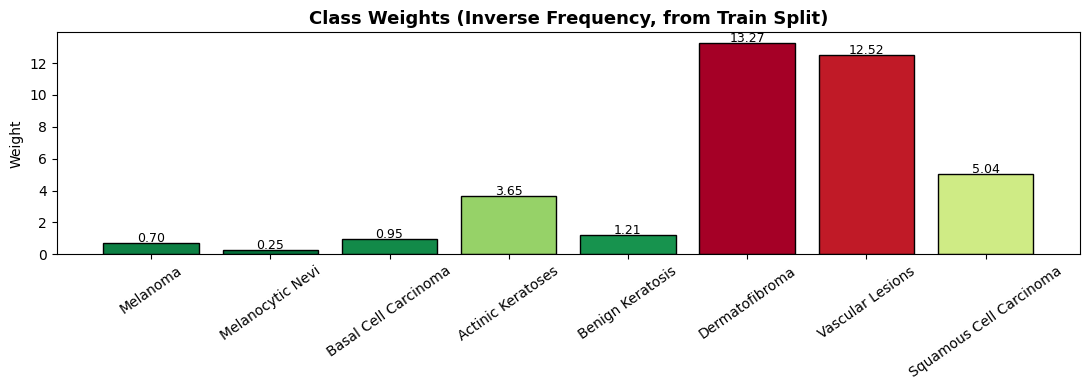

In [22]:
fig, ax = plt.subplots(figsize=(11, 4))
norm_weights = class_weights.values / class_weights.max()
bars = ax.bar(
    [CLASS_NAMES[c] for c in CLASSES],
    class_weights.values,
    color=plt.cm.RdYlGn_r(norm_weights),
    edgecolor='black'
)
ax.set_title('Class Weights (Inverse Frequency, from Train Split)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
ax.tick_params(axis='x', rotation=35)
for bar, w in zip(bars, class_weights.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{w:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Augmentation Pipelines

### Strategy
- **All splits** share the same resize + normalization (ImageNet stats for transfer learning).
- **Training — majority classes** (MEL, NV, BCC, BKL): standard augmentation.
- **Training — minority classes** (AK, DF, VASC, SCC): aggressive augmentation to synthetically expand rare samples.
- **Val / Test**: deterministic — resize + center crop + normalize only.

### Transforms
| Stage | Transform | Rationale |
|-------|-----------|----------|
| Both | Resize(256) + CenterCrop(224) | Uniform input size |
| Standard | RandomHorizontalFlip, RandomVerticalFlip | Lesion symmetry is not meaningful |
| Standard | RandomRotation(±30°) | Orientation-invariant features |
| Standard | ColorJitter(b=0.2, c=0.2, s=0.1, h=0.05) | Device/lighting variation |
| Aggressive | + RandomRotation(±180°) | Much wider rotation |
| Aggressive | + ColorJitter(b=0.4, c=0.4, s=0.2, h=0.1) | Stronger color shift |
| Aggressive | + RandomAffine(shear=15) | Shape deformation |
| Aggressive | + RandomErasing(p=0.3) | Simulate hair/occlusion artifacts |
| Aggressive | + GaussianBlur | Simulate out-of-focus dermoscopy |

In [23]:
# ── Shared base ────────────────────────────────────────────────────────────
normalize = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

# ── Val / Test (deterministic) ─────────────────────────────────────────────
val_test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    normalize,
])

# ── Train — standard augmentation (majority classes) ───────────────────────
train_transform_standard = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    normalize,
])

# ── Train — aggressive augmentation (minority classes) ─────────────────────
train_transform_aggressive = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=180),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomAffine(degrees=0, shear=15, scale=(0.85, 1.15)),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.ToTensor(),
    normalize,
    T.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

print('Transforms defined:')
print('  val_test_transform        (val + test)')
print('  train_transform_standard  (train: MEL, NV, BCC, BKL)')
print('  train_transform_aggressive(train: AK, DF, VASC, SCC)')

Transforms defined:
  val_test_transform        (val + test)
  train_transform_standard  (train: MEL, NV, BCC, BKL)
  train_transform_aggressive(train: AK, DF, VASC, SCC)


## 7. PyTorch Dataset & DataLoader

In [24]:
class ISICDataset(Dataset):
    """
    ISIC 2019 dataset with:
    - Per-class augmentation (aggressive for minority, standard for majority)
    - Optional metadata auxiliary features [age_norm, sex_enc, site_enc]
    """

    def __init__(
        self,
        df: pd.DataFrame,
        img_dir: Path,
        is_train: bool = False,
        use_metadata: bool = True,
        minority_classes: set = MINORITY_CLASSES,
    ):
        self.df              = df.reset_index(drop=True)
        self.img_dir         = Path(img_dir)
        self.is_train        = is_train
        self.use_metadata    = use_metadata
        self.minority_classes = minority_classes

        self.std_transform  = train_transform_standard
        self.agg_transform  = train_transform_aggressive
        self.eval_transform = val_test_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label_idx'])
        cls   = row['label']

        # ── Load image ──────────────────────────────────────────────────
        img_path = self.img_dir / (row['image'] + '.jpg')
        img = Image.open(img_path).convert('RGB')

        # ── Choose transform ─────────────────────────────────────────────
        if self.is_train:
            transform = (
                self.agg_transform
                if cls in self.minority_classes
                else self.std_transform
            )
        else:
            transform = self.eval_transform

        img_tensor = transform(img)

        # ── Metadata features ────────────────────────────────────────────
        if self.use_metadata:
            meta_feat = torch.tensor(
                [row['age_norm'], row['sex_enc'], row['site_enc']],
                dtype=torch.float32
            )
            return img_tensor, meta_feat, label

        return img_tensor, label


# ── Instantiate datasets ────────────────────────────────────────────────────
train_dataset = ISICDataset(train_df, IMG_DIR, is_train=True,  use_metadata=True)
val_dataset   = ISICDataset(val_df,   IMG_DIR, is_train=False, use_metadata=True)
test_dataset  = ISICDataset(test_df,  IMG_DIR, is_train=False, use_metadata=True)

print(f'Train dataset : {len(train_dataset):,} samples')
print(f'Val dataset   : {len(val_dataset):,} samples')
print(f'Test dataset  : {len(test_dataset):,} samples')

# Quick smoke-test: one sample
img_t, meta_t, lbl = train_dataset[0]
print(f'\nSample shapes — image: {img_t.shape}, meta: {meta_t.shape}, label: {lbl}')

Train dataset : 17,731 samples
Val dataset   : 3,800 samples
Test dataset  : 3,800 samples

Sample shapes — image: torch.Size([3, 224, 224]), meta: torch.Size([3]), label: 1


In [25]:
BATCH_SIZE   = 32
# num_workers > 0 requires pickling the Dataset class, which fails in Jupyter
# on macOS (spawn-based multiprocessing). Keep at 0 for notebook execution.
NUM_WORKERS  = 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Verify one batch
imgs, metas, labels = next(iter(train_loader))
print(f'\nBatch — images: {imgs.shape}, meta: {metas.shape}, labels: {labels.shape}')
print(f'Label distribution in batch: {dict(zip(*torch.unique(labels, return_counts=True)))}')

Train batches : 554
Val batches   : 119
Test batches  : 119

Batch — images: torch.Size([32, 3, 224, 224]), meta: torch.Size([32, 3]), labels: torch.Size([32])
Label distribution in batch: {tensor(0): tensor(5), tensor(1): tensor(16), tensor(2): tensor(5), tensor(4): tensor(5), tensor(6): tensor(1)}


## 8. Visualise Augmented Samples

Side-by-side: raw image vs. standard augmentation vs. aggressive augmentation.

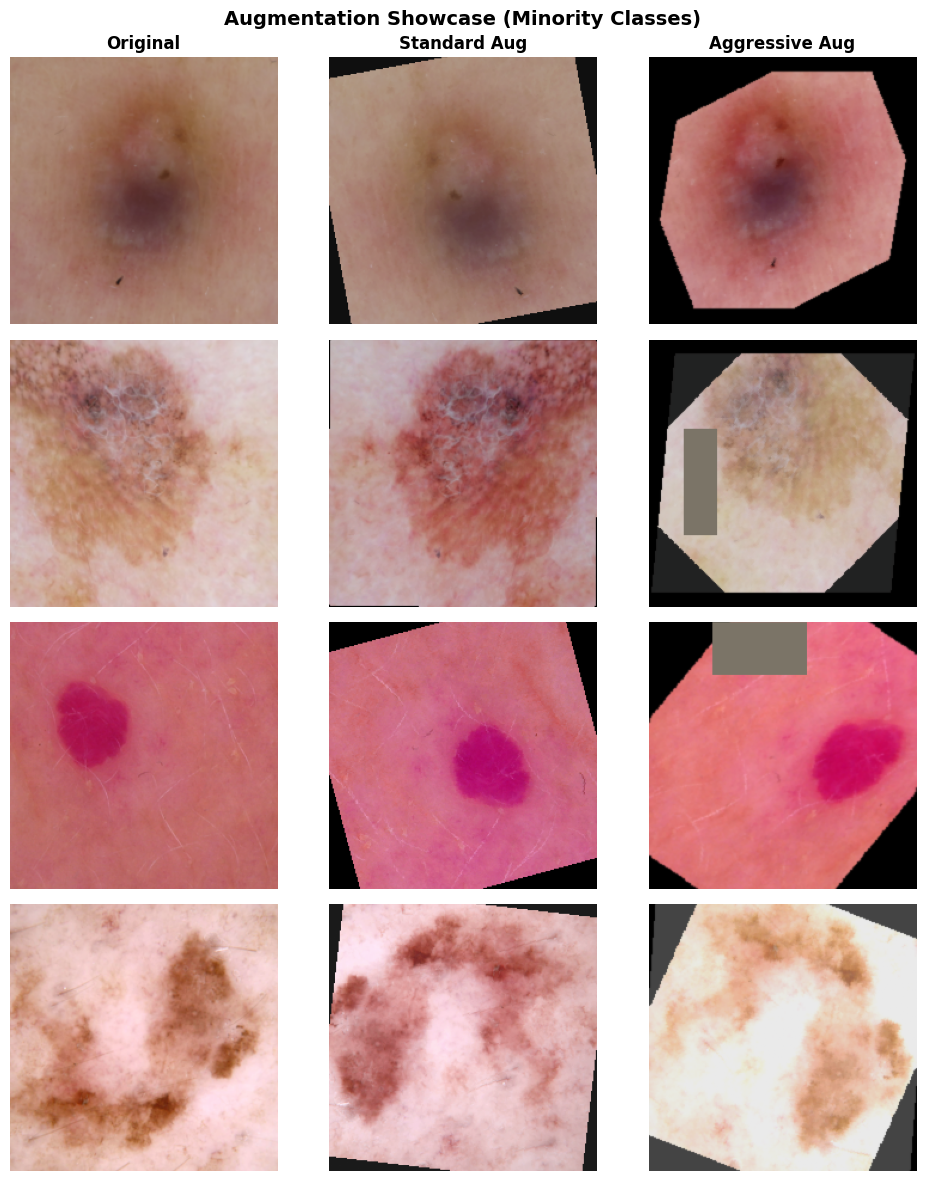

In [26]:
def denormalize(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


# Pick one sample per minority class for demonstration
showcase_classes = list(MINORITY_CLASSES)
to_tensor_only   = T.Compose([T.Resize(256), T.CenterCrop(IMG_SIZE)])  # raw resize, no norm

fig, axes = plt.subplots(len(showcase_classes), 3, figsize=(10, len(showcase_classes) * 3))
fig.suptitle('Augmentation Showcase (Minority Classes)', fontsize=14, fontweight='bold')
axes[0][0].set_title('Original', fontweight='bold')
axes[0][1].set_title('Standard Aug', fontweight='bold')
axes[0][2].set_title('Aggressive Aug', fontweight='bold')

for row_i, cls in enumerate(showcase_classes):
    sample_row = train_df[train_df['label'] == cls].sample(1, random_state=SEED).iloc[0]
    img_path   = IMG_DIR / (sample_row['image'] + '.jpg')
    raw_img    = Image.open(img_path).convert('RGB')

    std_aug = denormalize(train_transform_standard(raw_img))
    agg_aug = denormalize(train_transform_aggressive(raw_img))
    raw_disp = np.array(to_tensor_only(raw_img))

    axes[row_i][0].imshow(raw_disp)
    axes[row_i][1].imshow(std_aug)
    axes[row_i][2].imshow(agg_aug)

    for ax in axes[row_i]:
        ax.axis('off')
    axes[row_i][0].set_ylabel(f'{cls}\n{CLASS_NAMES[cls]}', fontsize=9,
                               fontweight='bold', rotation=0, labelpad=70,
                               ha='right', va='center')

plt.tight_layout()
plt.show()

## 9. Pixel Statistics Verification

Confirm ImageNet normalization is applied. Note: skin lesion images are red-heavy and won't perfectly center at 0 like natural ImageNet images — this is expected. The std values near ~1.0 confirm the normalization transform is active and correct for pretrained backbone compatibility.

In [27]:
# Check mean/std of a few batches from the train loader
all_means, all_stds = [], []
N_CHECK_BATCHES = 5

for i, (imgs, metas, labels) in enumerate(train_loader):
    if i >= N_CHECK_BATCHES:
        break
    # imgs shape: (B, 3, H, W)
    all_means.append(imgs.mean(dim=[0, 2, 3]).numpy())  # per-channel mean
    all_stds.append(imgs.std(dim=[0, 2, 3]).numpy())

mean_arr = np.array(all_means).mean(axis=0)
std_arr  = np.array(all_stds).mean(axis=0)

print('Batch pixel stats after ImageNet normalisation:')
print(f'  Mean (R, G, B) : {mean_arr.round(4)}')
print(f'  Std  (R, G, B) : {std_arr.round(4)}')
print('\n(Values should be close to 0 mean and ~1 std for correctly normalised data)')

Batch pixel stats after ImageNet normalisation:
  Mean (R, G, B) : [0.5963 0.1047 0.2994]
  Std  (R, G, B) : [1.1644 1.0699 1.0843]

(Values should be close to 0 mean and ~1 std for correctly normalised data)


## 10. Save Split CSVs

In [28]:
SAVE_COLS = ['image', 'label', 'label_idx', 'age_norm', 'sex_enc', 'site_enc']

train_df[SAVE_COLS].to_csv(OUT_DIR / 'train.csv', index=False)
val_df[SAVE_COLS].to_csv(OUT_DIR  / 'val.csv',   index=False)
test_df[SAVE_COLS].to_csv(OUT_DIR / 'test.csv',  index=False)

# Class index mapping
class_map = {i: {'abbrev': c, 'name': CLASS_NAMES[c]} for i, c in enumerate(CLASSES)}
with open(OUT_DIR / 'class_map.json', 'w') as f:
    json.dump(class_map, f, indent=2)

print('Saved to data_splits/:')
for fname in ['train.csv', 'val.csv', 'test.csv', 'class_weights.json',
              'class_map.json', 'meta_encoder_info.json']:
    fpath = OUT_DIR / fname
    print(f'  {fname:30s}  {fpath.stat().st_size / 1024:.1f} KB')

Saved to data_splits/:
  train.csv                       724.5 KB
  val.csv                         155.5 KB
  test.csv                        155.0 KB
  class_weights.json              0.1 KB
  class_map.json                  0.5 KB
  meta_encoder_info.json          0.3 KB


## 11. Preprocessing Summary

| Step | Decision | Rationale |
|------|----------|-----------|
| **Resize** | 256 → crop 224×224 | EfficientNet/ResNet/DenseNet standard; random crop adds translation jitter |
| **Normalisation** | ImageNet mean/std | Required for pretrained transfer-learning backbones |
| **Age imputation** | Per-class median | Preserves class-specific age distribution |
| **Site imputation** | `'unknown'` category | Treats missingness as informative signal |
| **Split** | Stratified 70/15/15 | Ensures all classes represented in every split |
| **Class weights** | Inverse frequency (train only) | Avoids data leakage; directly usable in `CrossEntropyLoss(weight=...)` |
| **Minority augmentation** | AK, DF, VASC, SCC get aggressive aug | Synthetically expands rarest classes without oversampling risk |
| **Majority augmentation** | MEL, NV, BCC, BKL get standard aug | Still improves generalisation without excessive distortion |
| **RandomErasing** | Minority train only | Simulates hair / ruler artifacts common in dermoscopy |
| **Metadata features** | age_norm, sex_enc, site_enc | Optional auxiliary input for metadata-fused models |

### Outputs (in `data_splits/`)
| File | Contents |
|------|----------|
| `train.csv` | 17,731 rows with encoded features |
| `val.csv`   | 3,800 rows |
| `test.csv`  | 3,800 rows |
| `class_weights.json` | `{class: weight}` for loss function |
| `class_map.json` | `{idx: {abbrev, name}}` for decoding predictions |
| `meta_encoder_info.json` | Encoders for age/sex/site at inference time |